# §3.3 Process Discovery (Task 1)

Three discovery algorithms on the filtered BPIC-17 log:

- Alpha Miner -> weak baseline, expected unsound on this log (Lecture 2).
- Heuristics Miner -> dependency-graph, noise-robust (Lecture 2).
- Inductive Miner -> sound workflow nets, fitness-strong (Leemans et al. 2013, pm4py default).

Each model is exported to models/.pnml, rendered to results/figures/, and compared by size and control-flow complexity. Quality metrics follow in notebook 03.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

from src.seeds import set_all_seeds
from src.simplicity_metrics import size as petri_size, control_flow_complexity
set_all_seeds()

import pm4py
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

for _d in ("../models", "../results/figures"):
    Path(_d).mkdir(parents=True, exist_ok=True)


## 1. Load the filtered event log (cached from Notebook 01)


In [2]:
CASE_COL = "case:concept:name"
ACT_COL  = "concept:name"
TS_COL   = "time:timestamp"

df = pd.read_pickle("../data/bpic17_filtered.pkl")
print(f"Filtered log: {df[CASE_COL].nunique():,} cases, {len(df):,} events, {df[ACT_COL].nunique()} activities")
df.head(2)


Filtered log: 31,361 cases, 473,139 events, 24 activities


,Action,org:resource,concept:name,EventOrigin,EventID,lifecycle:transition,time:timestamp,case:LoanGoal,case:ApplicationType,case:concept:name,case:RequestedAmount,FirstWithdrawalAmount,NumberOfTerms,Accepted,MonthlyCost,Selected,CreditScore,OfferedAmount,OfferID
116,Created,User_1,A_Create Application,Application,Application_1746793196,complete,2016-01-01 12:34:53.911000+00:00,Car,New credit,Application_1746793196,5000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
117,statechange,User_1,A_Submitted,Application,ApplState_282472804,complete,2016-01-01 12:34:53.950000+00:00,Car,New credit,Application_1746793196,5000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Alpha Miner

Non-parametric: builds a workflow net from the footprint matrix.

Alpha:      25 places, 24 transitions, 87 arcs (0.9s)


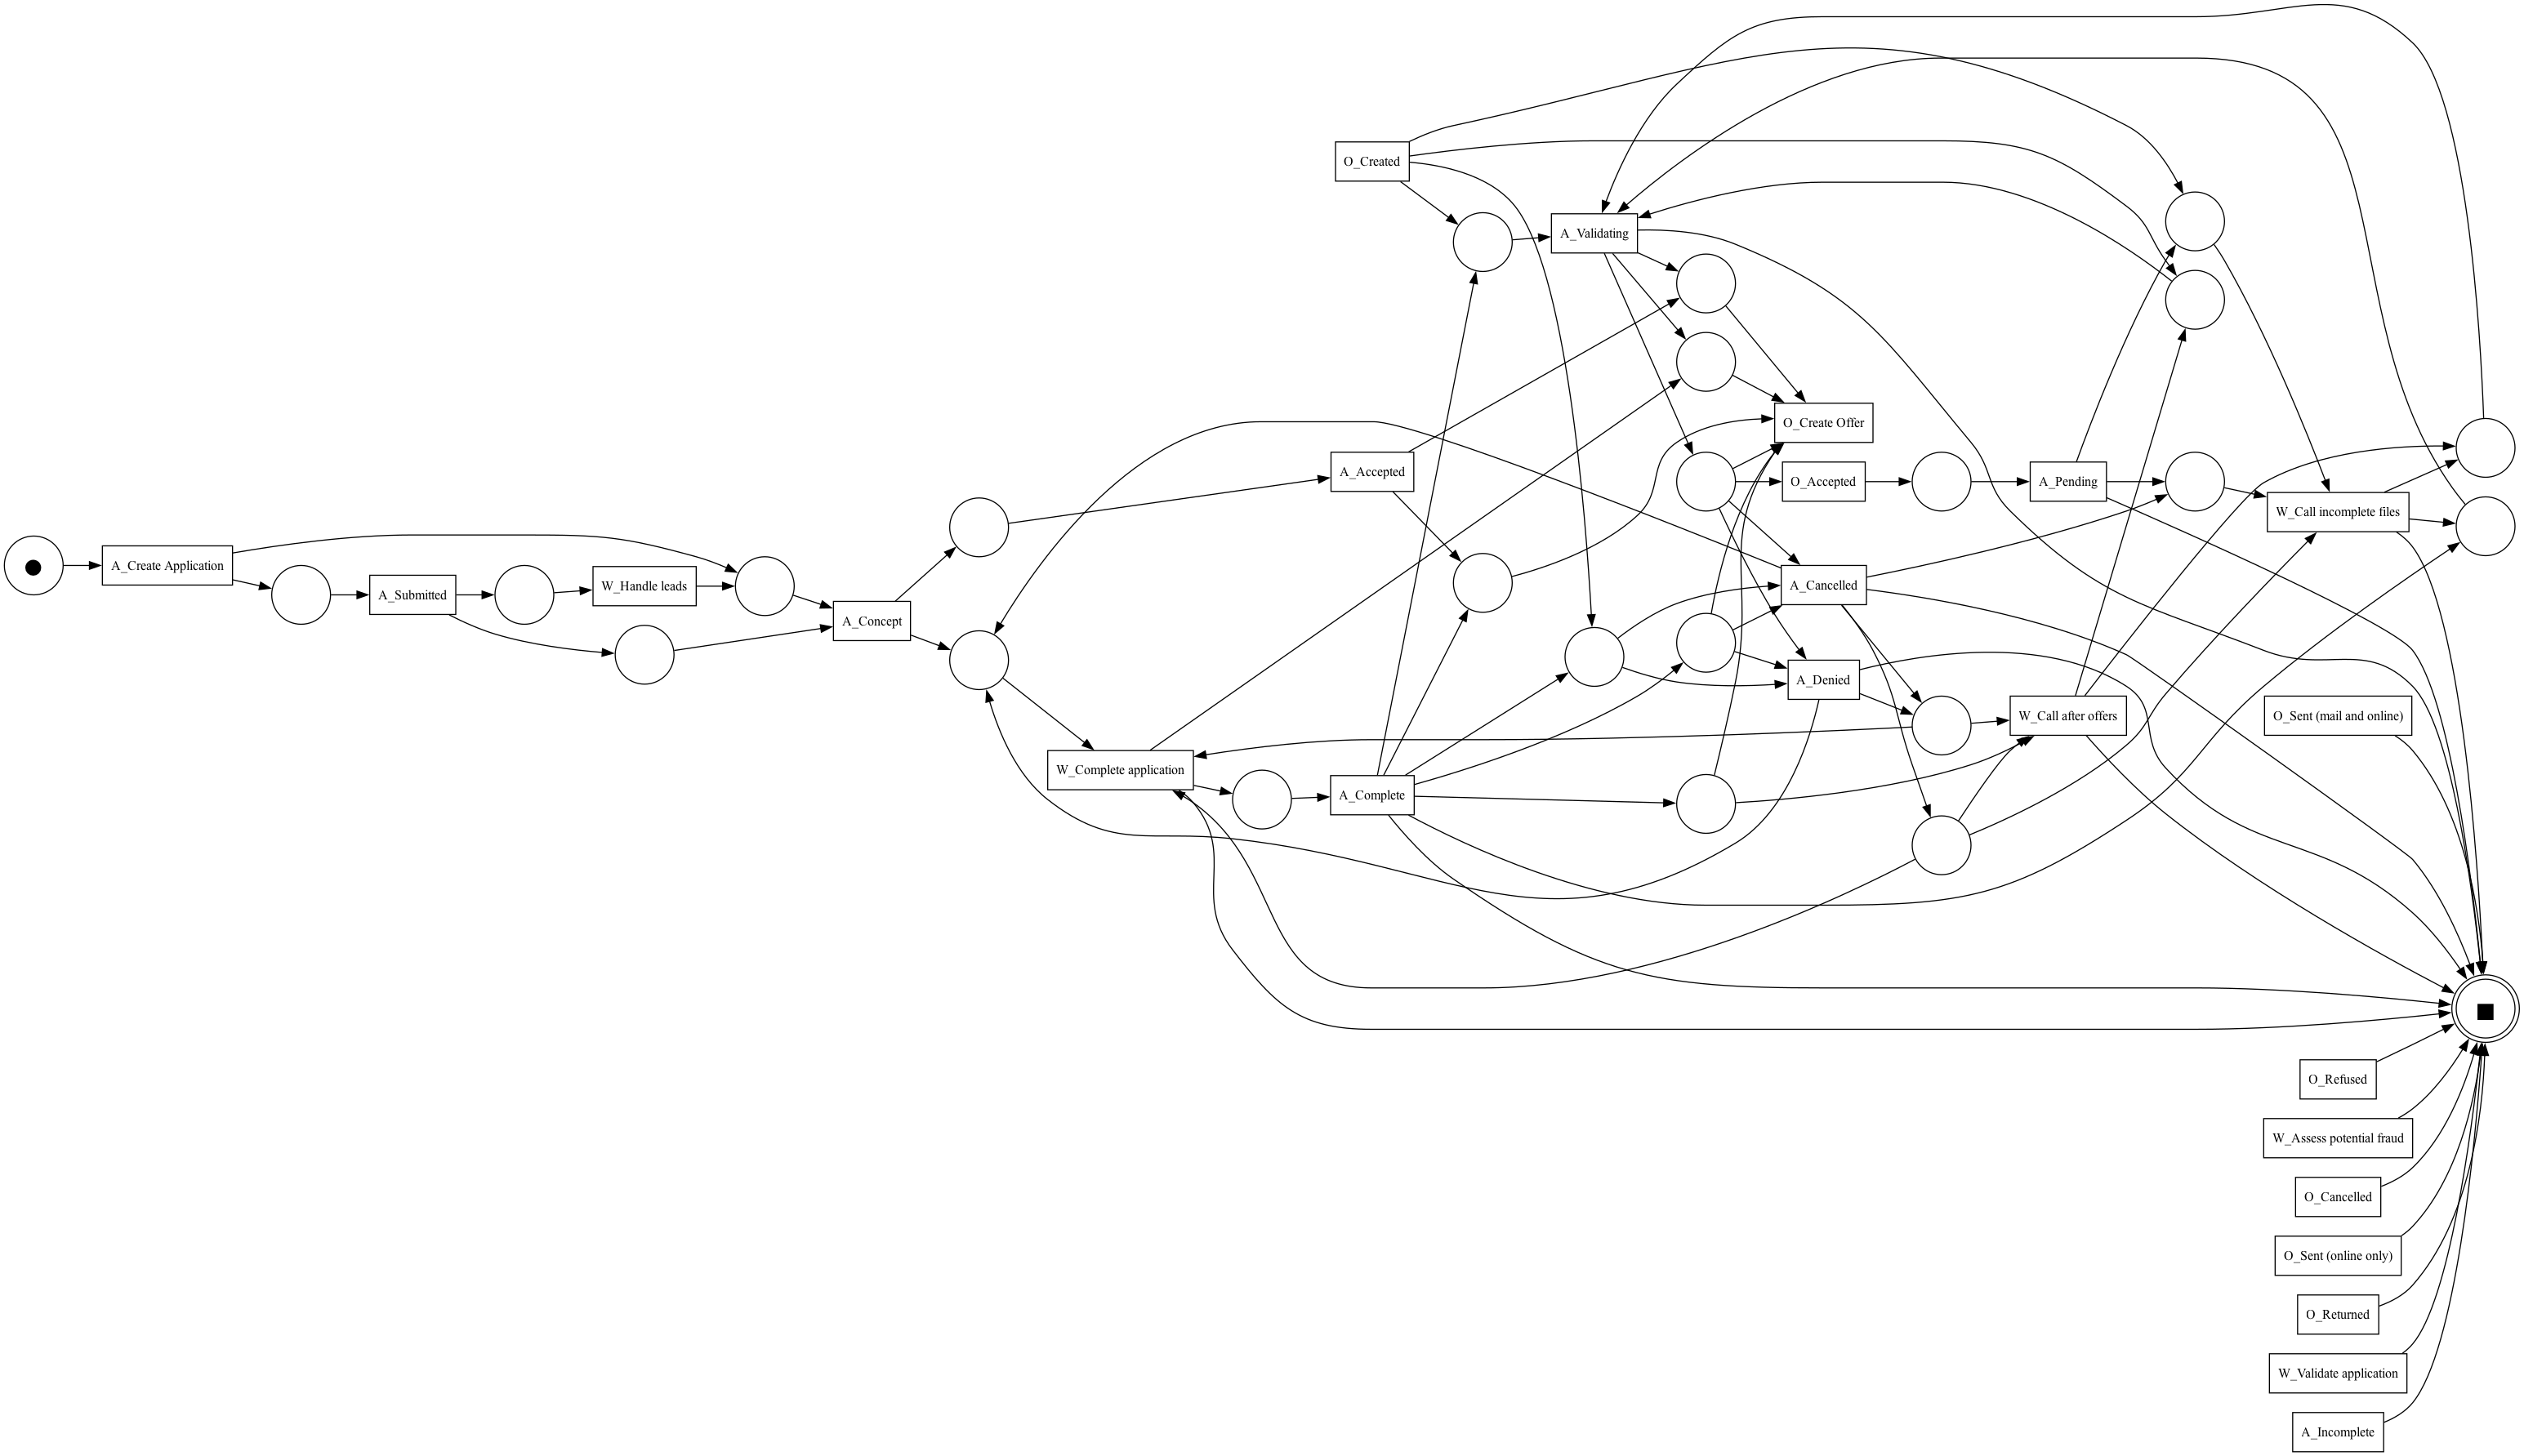

In [3]:
import time

t0 = time.time()
net_a, im_a, fm_a = pm4py.discover_petri_net_alpha(df)
print(f"Alpha:      {len(net_a.places)} places, {len(net_a.transitions)} transitions, {len(net_a.arcs)} arcs ({time.time()-t0:.1f}s)")

pm4py.write_pnml(net_a, im_a, fm_a, "../models/alpha.pnml")
pm4py.save_vis_petri_net(net_a, im_a, fm_a, "../results/figures/discovery_alpha.png")
pm4py.view_petri_net(net_a, im_a, fm_a, format="png")

## 3. Heuristics Miner

DFG-based with dependency-score thresholds: robust to infrequent behaviour.

Heuristics: 49 places, 94 transitions, 220 arcs (2.4s)


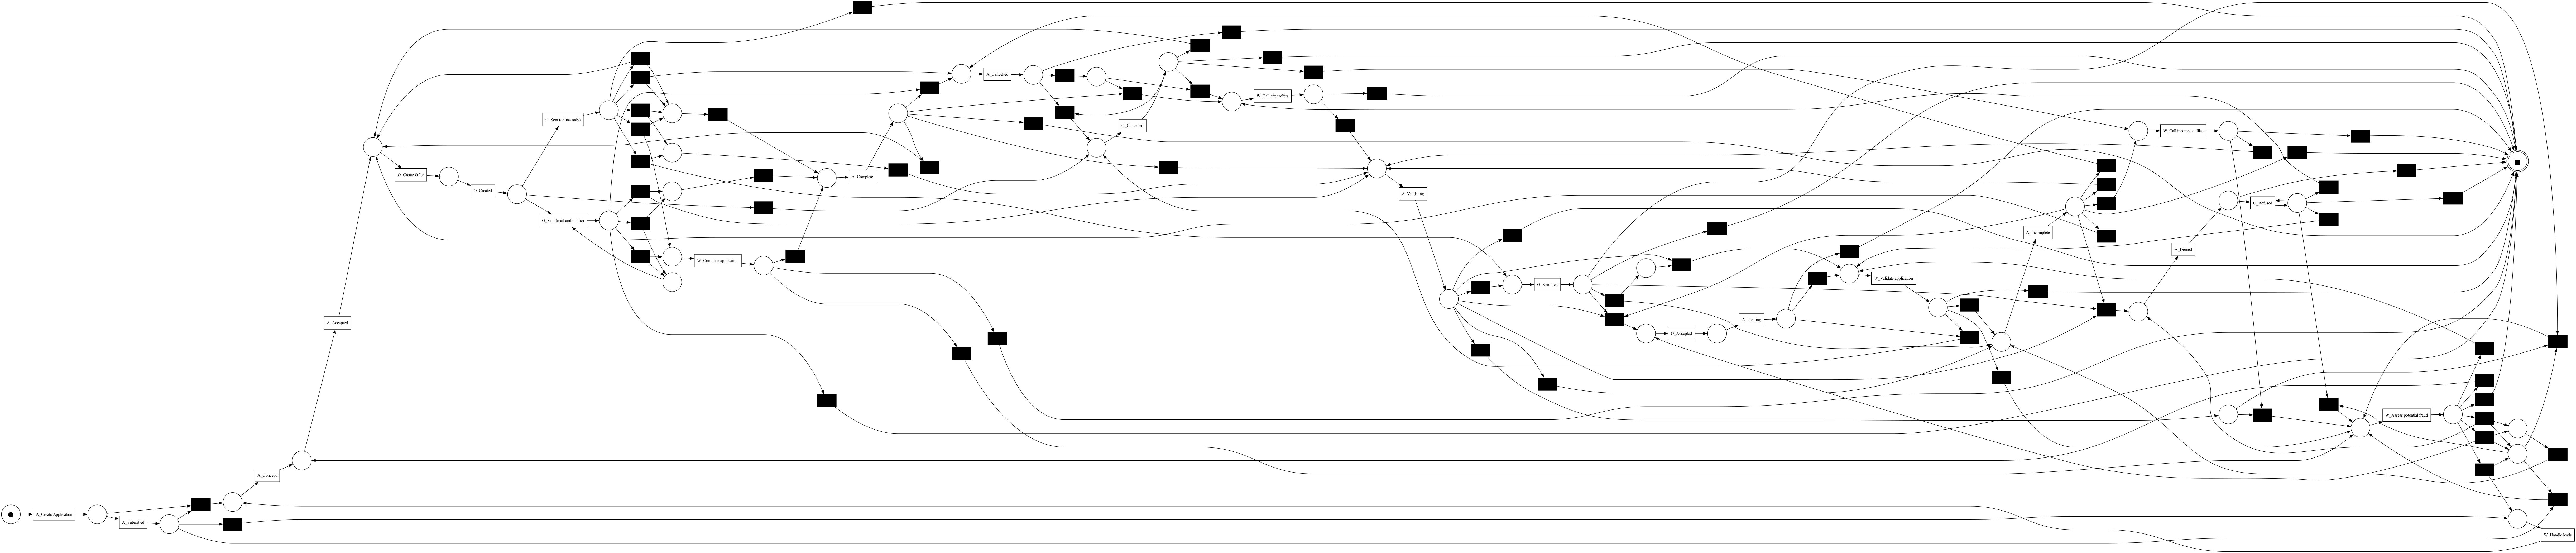

In [4]:
t0 = time.time()
net_h, im_h, fm_h = pm4py.discover_petri_net_heuristics(df, dependency_threshold=0.5)
print(f"Heuristics: {len(net_h.places)} places, {len(net_h.transitions)} transitions, {len(net_h.arcs)} arcs ({time.time()-t0:.1f}s)")

pm4py.write_pnml(net_h, im_h, fm_h, "../models/heuristics.pnml")
pm4py.save_vis_petri_net(net_h, im_h, fm_h, "../results/figures/discovery_heuristics.png")
pm4py.view_petri_net(net_h, im_h, fm_h, format="png")

## 4. Inductive Miner

Sound workflow net via recursive process-tree decomposition. noise_threshold=0.2 discards trace variants below 20 % share, trading fitness for precision and simplicity.

Inductive:  30 places, 49 transitions, 102 arcs (5.5s)


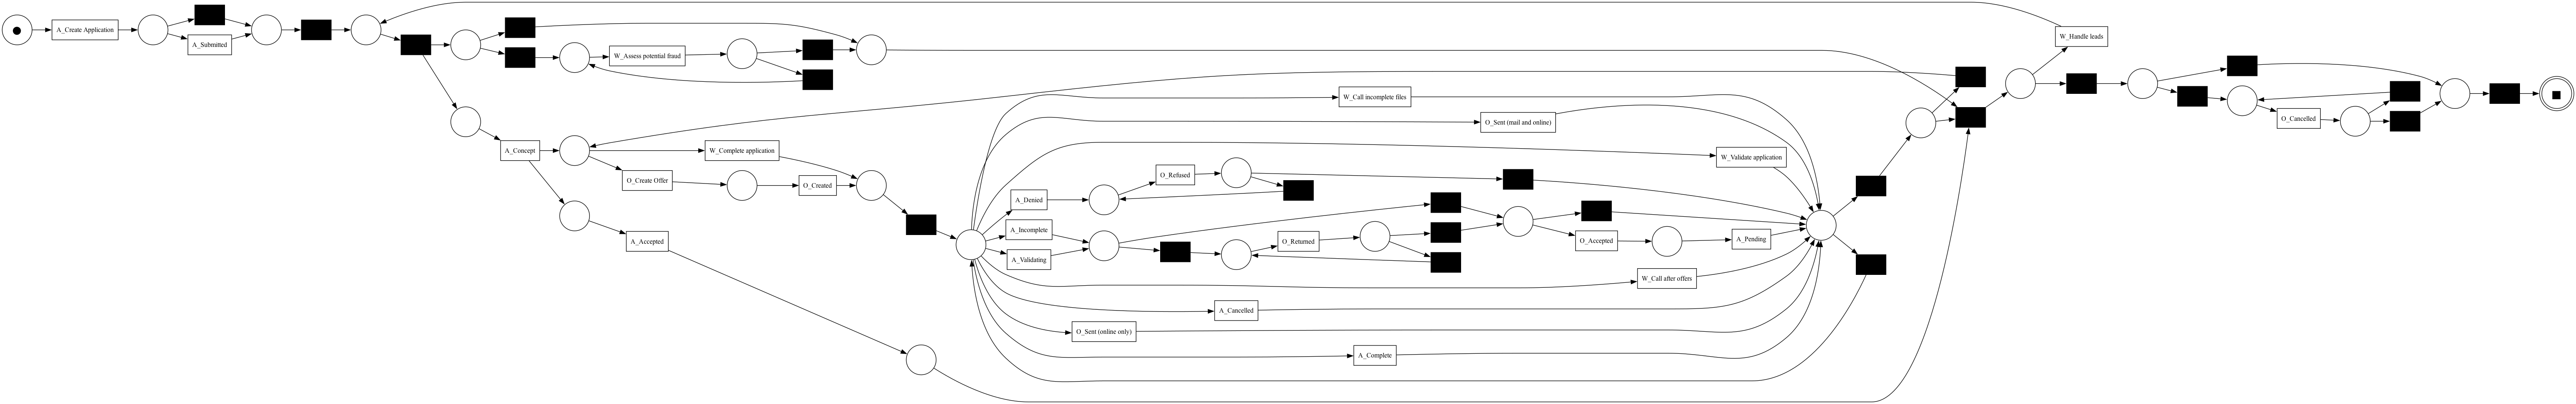

In [5]:
t0 = time.time()
net_i, im_i, fm_i = pm4py.discover_petri_net_inductive(df, noise_threshold=0.2)
print(f"Inductive:  {len(net_i.places)} places, {len(net_i.transitions)} transitions, {len(net_i.arcs)} arcs ({time.time()-t0:.1f}s)")

pm4py.write_pnml(net_i, im_i, fm_i, "../models/inductive.pnml")
pm4py.save_vis_petri_net(net_i, im_i, fm_i, "../results/figures/discovery_inductive.png")
pm4py.view_petri_net(net_i, im_i, fm_i, format="png")

## 5. Structural comparison

Compare model size (a first simplicity proxy) and the self-implemented Cardoso control-flow complexity (src.simplicity_metrics.control_flow_complexity).

In [6]:
models = {
    "Alpha":      net_a,
    "Heuristics": net_h,
    "Inductive":  net_i,
}

rows = []
for name, net in models.items():
    rows.append({
        "Model":       name,
        "|P| places":  len(net.places),
        "|T| transitions": len(net.transitions),
        "|F| arcs":    len(net.arcs),
        "Size = |P|+|T|+|F|": petri_size(net),
        "CFC":         control_flow_complexity(net),
    })

comparison = pd.DataFrame(rows).set_index("Model")
comparison.to_csv("../results/discovery_comparison.csv")
comparison.to_latex(
    "../results/discovery_comparison.tex",
    column_format="lrrrrr",
    caption="Structural comparison of the three discovered Petri nets on the filtered BPIC-17 log.",
    label="tab:discovery_comparison",
)
comparison


,|P| places,|T| transitions,|F| arcs,Size = |P|+|T|+|F|,CFC
Model,,,,,
Alpha,25,24,87,136,29
Heuristics,49,94,220,363,98
Inductive,30,49,102,181,38


## 6. Render thumbnails inline (sanity check)

Full PNGs are in results/figures/. the inline preview confirms the saves worked.

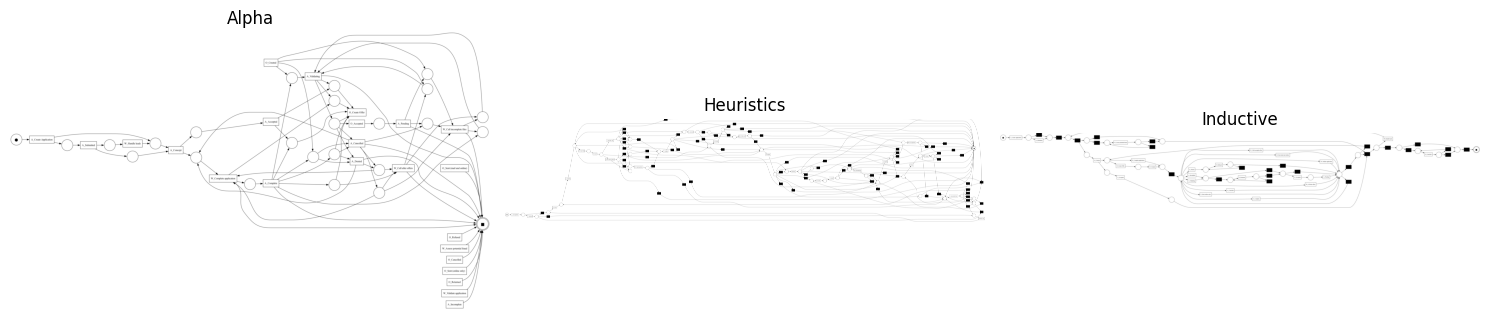

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (name, _) in zip(axes, models.items()):
    img = plt.imread(f"../results/figures/discovery_{name.lower()}.png")
    ax.imshow(img)
    ax.set_title(name)
    ax.axis("off")
plt.tight_layout()
plt.savefig("../results/figures/discovery_overview.png", dpi=120)
plt.show()
